In [361]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

X = np.load("X_train.npy")
y = np.load("y_train.npy")

In [362]:
print(X.shape)
print(y.shape)

print(X)

(996, 10, 1)
(996,)
[[[2.35523287e-02]
  [3.26507460e-02]
  [2.79863795e-02]
  ...
  [1.09420255e-03]
  [3.97346453e-03]
  [7.54367360e-03]]

 [[3.26507460e-02]
  [2.79863795e-02]
  [3.62790077e-03]
  ...
  [3.97346453e-03]
  [7.54367360e-03]
  [8.58022957e-03]]

 [[2.79863795e-02]
  [3.62790077e-03]
  [5.18323089e-04]
  ...
  [7.54367360e-03]
  [8.58022957e-03]
  [0.00000000e+00]]

 ...

 [[7.24456722e-01]
  [7.06443833e-01]
  [7.33168844e-01]
  ...
  [7.16863070e-01]
  [6.48637389e-01]
  [6.09550388e-01]]

 [[7.06443833e-01]
  [7.33168844e-01]
  [7.10740984e-01]
  ...
  [6.48637389e-01]
  [6.09550388e-01]
  [5.86828252e-01]]

 [[7.33168844e-01]
  [7.10740984e-01]
  [6.98379084e-01]
  ...
  [6.09550388e-01]
  [5.86828252e-01]
  [5.43856015e-01]]]


In [363]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
y = y.view(-1, 1)

X = X.squeeze()

In [364]:
class StockPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(10, 32)
        self.layer2 = nn.Linear(32, 16)
        self.layer3 = nn.Linear(16, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)

        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.layer3(x)
        return x

model = StockPredictor()

In [365]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    predictions = model(X)

    loss = criterion(predictions, y)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())
    
    
    


Epoch: 0 Loss: 0.25365471839904785
Epoch: 10 Loss: 0.19196105003356934
Epoch: 20 Loss: 0.12670989334583282
Epoch: 30 Loss: 0.056523941457271576
Epoch: 40 Loss: 0.010082491673529148
Epoch: 50 Loss: 0.0029152128845453262
Epoch: 60 Loss: 0.004206135403364897
Epoch: 70 Loss: 0.0017931718612089753
Epoch: 80 Loss: 0.0015854497905820608
Epoch: 90 Loss: 0.0013418830931186676


In [366]:
model.eval()
with torch.no_grad():
    last_window = X[-1]
    last_window = last_window.unsqueeze(0)

    predicted_price = model(last_window)

    prediction_value = predicted_price.item()

print("Predicted next price:", prediction_value)

import numpy as np
from sklearn.preprocessing import MinMaxScaler

from prepare_data import scaler

prediction = prediction_value

prediction = np.array([[prediction]])

real_price = scaler.inverse_transform(prediction)

print("Predicted next price:", real_price[0][0])

Predicted next price: 0.6862729787826538
Predicted next price: 232.85854219231075


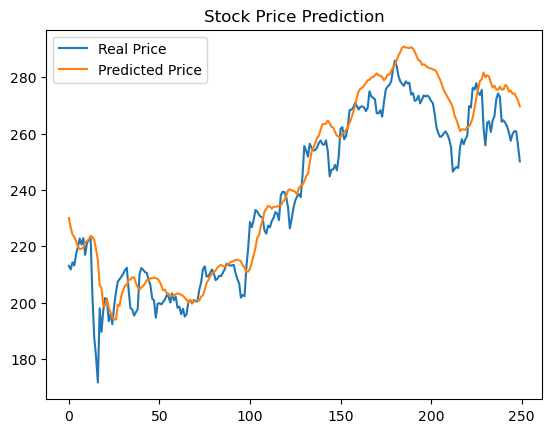

In [367]:
model.eval()

X = np.load("X_test.npy")
y = np.load("y_test.npy")

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
y = y.view(-1, 1)

X = X.squeeze()

with torch.no_grad():
    predictions = model(X)

predictions = predictions.numpy()

predictions = scaler.inverse_transform(predictions)
real_y = scaler.inverse_transform(y.numpy())

import matplotlib.pyplot as plt

plt.plot(real_y, label="Real Price")
plt.plot(predictions, label="Predicted Price")

plt.legend()
plt.title("Stock Price Prediction")
plt.show()